# Credit Card Fraud Detection

## Why important?
Bilions of dollars are lost anually, because of unauthorized 3rd party use. Even though it will not solve the problem completly, machine learning techniques can help detect the fraud and analyze data that can be later used to improve security measures.

This project will be separated into parts:
    1. exploration and inspecting the data
    2. trying out different models
    3. evaluation of the results

The dataset used for this project, can be found under the [link](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).

In [1]:
#import the libraries
import pandas as pd
import numpy as np
from sklearn import svm, model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from matplotlib import pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report

# for reproducility
RANDOM_STATE = 42

# Load & explore the data
The dataset is from 2013 years with transaction made by European cardholders. 

In [2]:
#read the file
file_path = "creditcard.csv"
data = pd.read_csv(file_path)

data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


We have 30 features, where two of them `Time` and `Amount` are original figures. `V1`-`V28` are features obtained with PCA to ensure privacy. 
There are 284 807 different transaction, with `Time` representing seconds elapsed between each transaction and the first one. `Amount` represents the value of a transaction.

`Class` label is our target with binary values 0 and 1, representing valid transaction and fraud respectively.

# Class Distribution

Now we take a look at how `Class` label is distributed in our dataset to have a better feeling of what we are dealing with.

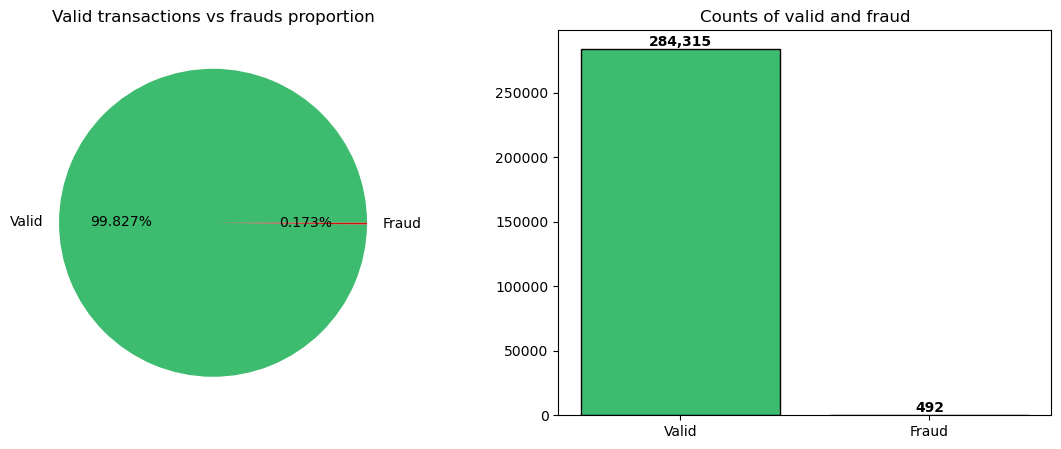

In [3]:
# count the occurences of valid transactions and fraud, setting colors for plots
counts = data["Class"].value_counts()
colors = ["#3dbb6f", "#da0d0d"]

# creating plots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# pie chart
ax[0].pie(counts, labels=["Valid", "Fraud"], autopct="%1.3f%%", colors=colors)
ax[0].set_title("Valid transactions vs frauds proportion")

# bar chart
ax[1].bar(["Valid", "Fraud"], counts, color=colors, edgecolor="black")
ax[1].bar_label(ax[1].containers[0], fmt='{:,.0f}', fontweight='bold')
ax[1].set_title("Counts of valid and fraud")

plt.show()


Looking at the figures, almost all (99.83%) of transaction are valid ones. Therefore one could make a `Naive` model that just sets every transaction to a valid one and such a model would achieve accurary of almost 100%. However, this would not capture any fraud and would be totally useless in our case. 

# Check if there are any coorelations
We check if the `Class` labels have any coorelation with `Amount` and `Time`

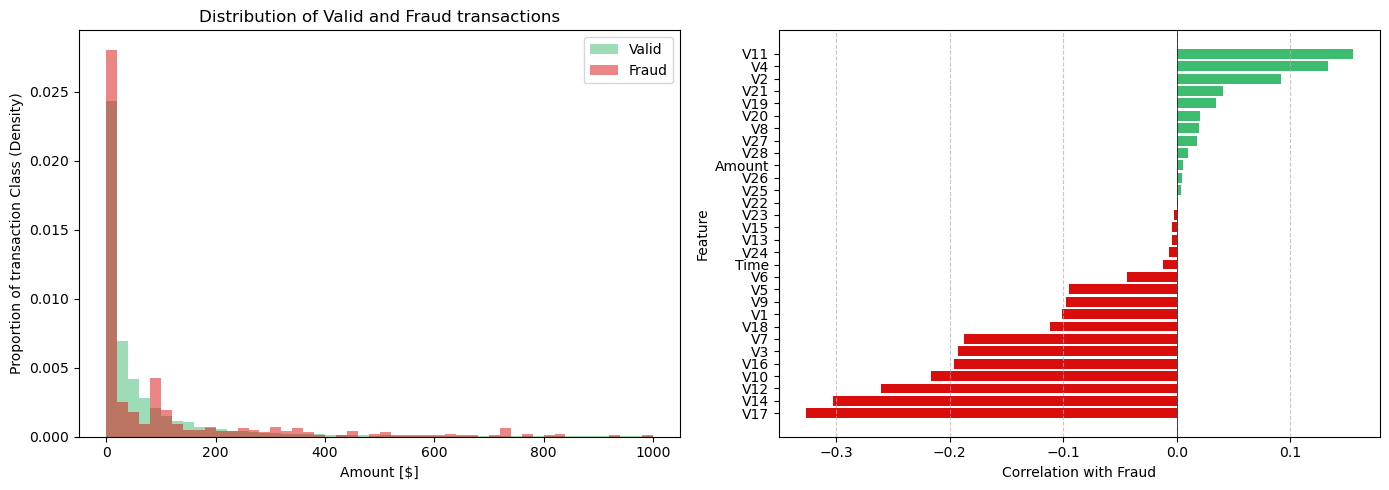

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# create a historgram showing the density vs amount 
ax[0].hist(data[data["Class"] == 0]["Amount"], bins=50, range=(0, 1000), stacked=True, color=colors[0], label=["Valid"], alpha=0.5, density=True)
ax[0].hist(data[data["Class"] == 1]["Amount"], bins=50, range=(0, 1000), stacked=True, color=colors[1], label=["Fraud"], alpha=0.5, density=True)
ax[0].set_title("Distribution of Valid and Fraud transactions")
ax[0].set_xlabel("Amount [$]")
ax[0].set_ylabel("Proportion of transaction Class (Density)")
ax[0].legend()

# creating a correlation plot
correlations = data.corr()["Class"].drop("Class").sort_values()

ax[1].barh(correlations.index, correlations.values, color=[colors[0] if x>0 else colors[1] for x in correlations])
ax[1].set_xlabel("Correlation with Fraud")
ax[1].set_ylabel("Feature")
ax[1].axvline(x=0, color="black", linewidth=0.5)
ax[1].xaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()



plt.show()

Looking at the left figure, we can see that for both categories, the most transactions were made for a small amount. This is also a place where most fraud transactions took place.
From the right figure, we can see how the Fraud is correlated with different features. We can see that `V17` has the strongest negative correlation, while `V11` has the strongest positive correlation. 

# Training the models
First we need to split the data we have into train and test splits. 
We will use `SVM` Classifier, `Random Forest` and `Logistic Regression` and comapre them to find which models performs best.

In [5]:
# split the data into features X and target Y 
X = data.drop(columns=["Time", "Class"])
Y = data["Class"]

# test split the data
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X, Y, test_size=0.2)

# dict of models to compare for easier implementation
models = {
    "SVM": svm.SVC(max_iter=3000, random_state=RANDOM_STATE),
    "RandomForest" : RandomForestClassifier(random_state=RANDOM_STATE),
    "LogisticRegression" : LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)
}

In [6]:
# storing the results for easier comparision
results = {}

for model_name in models:
    model = models[model_name]
    print(f"Training {model_name}")
    model.fit(X_train, Y_train)
    
    prediction = model.predict(X_test)
    
    results[model_name] = {
        "name" : model_name,
        "prediction" : prediction,
        "f1" : f1_score(Y_test, prediction), 
        "ROC_AUC" : roc_auc_score(Y_test, prediction)
    }
    print(f"Finished fitting and prediction with {model_name}")
print("All models are done!")
    

Training SVM
Finished fitting and prediction with SVM
Training RandomForest
Finished fitting and prediction with RandomForest
Training LogisticRegression
Finished fitting and prediction with LogisticRegression
All models are done!


In [7]:
for model in results:
    print(results[model])

{'name': 'SVM', 'prediction': array([0, 0, 0, ..., 0, 0, 0]), 'f1': 0.5733333333333334, 'ROC_AUC': 0.7215615569883818}
{'name': 'RandomForest', 'prediction': array([0, 0, 0, ..., 0, 0, 0]), 'f1': 0.8202247191011236, 'ROC_AUC': 0.876218317755654}
{'name': 'LogisticRegression', 'prediction': array([0, 0, 0, ..., 0, 0, 0]), 'f1': 0.75, 'ROC_AUC': 0.8246719260030766}


After training, we can print the results to see how each model performed on the test data.
For that we will use a function from `sklearn` module, called `classification_report`

In [8]:
for model in results:
    print("="*60)
    print(results[model]["name"])
    print("="*60)
    print(classification_report(Y_test, results[model]["prediction"], target_names=["Valid", "Fraud"]))

SVM
              precision    recall  f1-score   support

       Valid       1.00      1.00      1.00     56865
       Fraud       0.81      0.44      0.57        97

    accuracy                           1.00     56962
   macro avg       0.91      0.72      0.79     56962
weighted avg       1.00      1.00      1.00     56962

RandomForest
              precision    recall  f1-score   support

       Valid       1.00      1.00      1.00     56865
       Fraud       0.90      0.75      0.82        97

    accuracy                           1.00     56962
   macro avg       0.95      0.88      0.91     56962
weighted avg       1.00      1.00      1.00     56962

LogisticRegression
              precision    recall  f1-score   support

       Valid       1.00      1.00      1.00     56865
       Fraud       0.89      0.65      0.75        97

    accuracy                           1.00     56962
   macro avg       0.94      0.82      0.87     56962
weighted avg       1.00      1.00     

Looking at the evaluation metrics, each model perfectly predicts the transactions that are marked as `Valid`. However, this is not a difficult task, since as shown earlier - 99.827% of all the transaction in the data set are marked as `Valid`. The main task is to catch transactions that are `Fraud` and which make a great minority in the dataset. For that we look at F1 score, that is harmonic mean of precision and recall. 

Now let's plot the ROC curves, to see the compared performance of models on the graph.

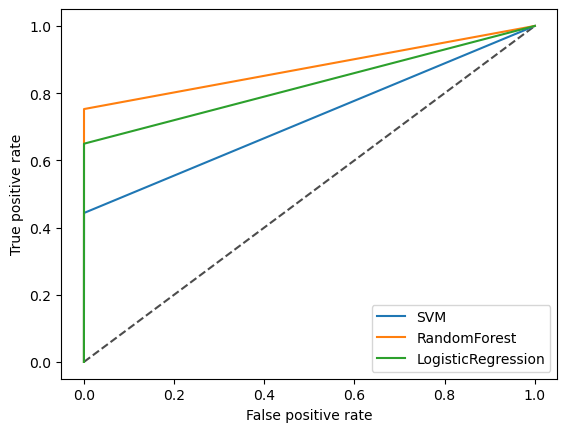

In [33]:
plt.plot([0, 1], [0, 1], linestyle="dashed", color="black", alpha=0.7)
for model in models:
    fpr, tpr = roc_curve(Y_test, results[model]["prediction"])[:2]
    plt.plot(fpr, tpr, label=model)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()